### Open-air area classifier

In [ ]:
import os
import time
import random

import pandas as pd
import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import keras

In [2]:
# Zadanie 6
# 1)
data = {}
with np.load("Intel_Image.npz") as f:
    data["train_img"] = f["train_img"]
    data["train_lab"] = f["train_lab"]
    data["test_img"] = f["test_img"]
    data["test_lab"] = f["test_lab"]

# 2)
X_train = data["train_img"]
y_train = data["train_lab"]
X_test = data["test_img"]
y_test = data["test_lab"]

# 3)
# Data is ~ 14k recods for train set and 3k for test set. Each record is 126x126 array with 3 values representing R, G, B channels values
print(f"Shapes of arrays: train_set: ({X_train.shape}) test_set: ({X_test.shape})")
print(f"Types of arrays: train_set: ({X_train.dtype}) test_set: ({X_test.dtype})")
print(f"Check wheter the data in 126x126 2D array is alredy scaled: train set min val: {X_train.min()} max val: {X_train.max()}")
print(f"Check wheter the data in 126x126 2D array is alredy scaled: test set min val: {X_test.min()} max val: {X_test.max()}\n")


NUM_CLASSES_TRAIN = len(set(y_train))
NUM_CLASSES_TEST = len(set(y_test))
if NUM_CLASSES_TRAIN != NUM_CLASSES_TEST:
    raise ValueError("Number of unique classes in train set and test set are different")

print(f"Types of labels: train: ({y_train.dtype}) test: ({y_test.dtype})")
print(f"Labels range from {y_train.min()} to {y_test.max()} - total unique labels: {NUM_CLASSES_TRAIN}")

Shapes of arrays: train_set: ((14034, 126, 126, 3)) test_set: ((3000, 126, 126, 3))
Types of arrays: train_set: (float32) test_set: (float32)
Check wheter the data in 126x126 2D array is alredy scaled: train set min val: 0.0 max val: 1.0
Check wheter the data in 126x126 2D array is alredy scaled: test set min val: 0.0 max val: 1.0

Types of labels: train: (int8) test: (int8)
Labels range from 0 to 5 - total unique labels: 6


Text(0.5, 1.0, 'Rozkład klas w zbiorze treningowym')

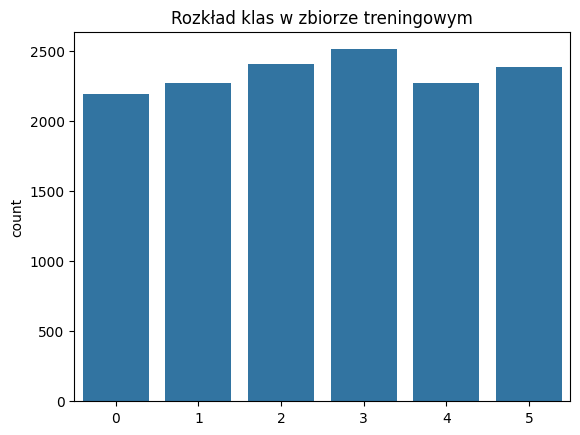

In [3]:
sns.countplot(x=y_train).set_title("Rozkład klas w zbiorze treningowym")

Text(0.5, 1.0, 'Rozkład klas w zbiorze testowym')

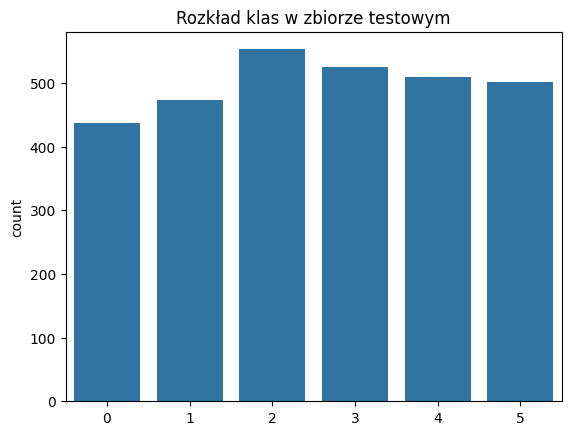

In [4]:
sns.countplot(x=y_test).set_title("Rozkład klas w zbiorze testowym")

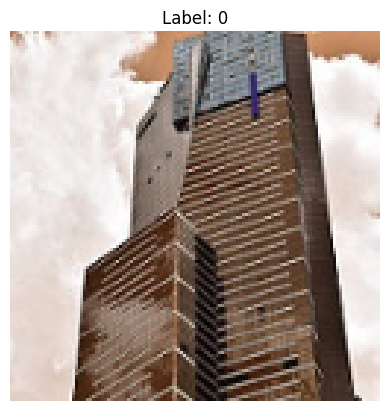

In [5]:
# 4)
plt.imshow(X_test[0], interpolation='nearest')
plt.axis("off")
plt.title(f"Label: {y_train[0]}")
plt.show()

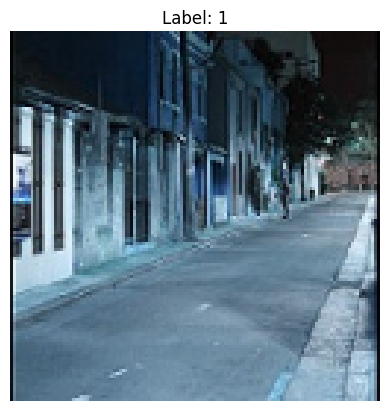

In [6]:
last_rec_idx = len(X_test) -1
plt.imshow(X_test[last_rec_idx], interpolation='nearest')
plt.axis("off")
plt.title(f"Label: {y_train[last_rec_idx]}")
plt.show()

In [7]:
# Zadanie 7
# 1)
model = keras.models.Sequential([
    keras.layers.Input(shape=(126, 126, 3)),
    keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation="relu"),
    keras.layers.Dense(units=64, activation="relu"),
    keras.layers.Dense(units=NUM_CLASSES_TRAIN, activation="softmax")
])

2026-04-15 00:02:11.731359: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-04-15 00:02:11.731386: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-04-15 00:02:11.731392: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1776204131.731409 4506678 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1776204131.731424 4506678 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,715,430 (14.17 MB)

 Trainable params: 3,715,430 (14.17 MB)

 Non-trainable params: 0 (0.00 B)

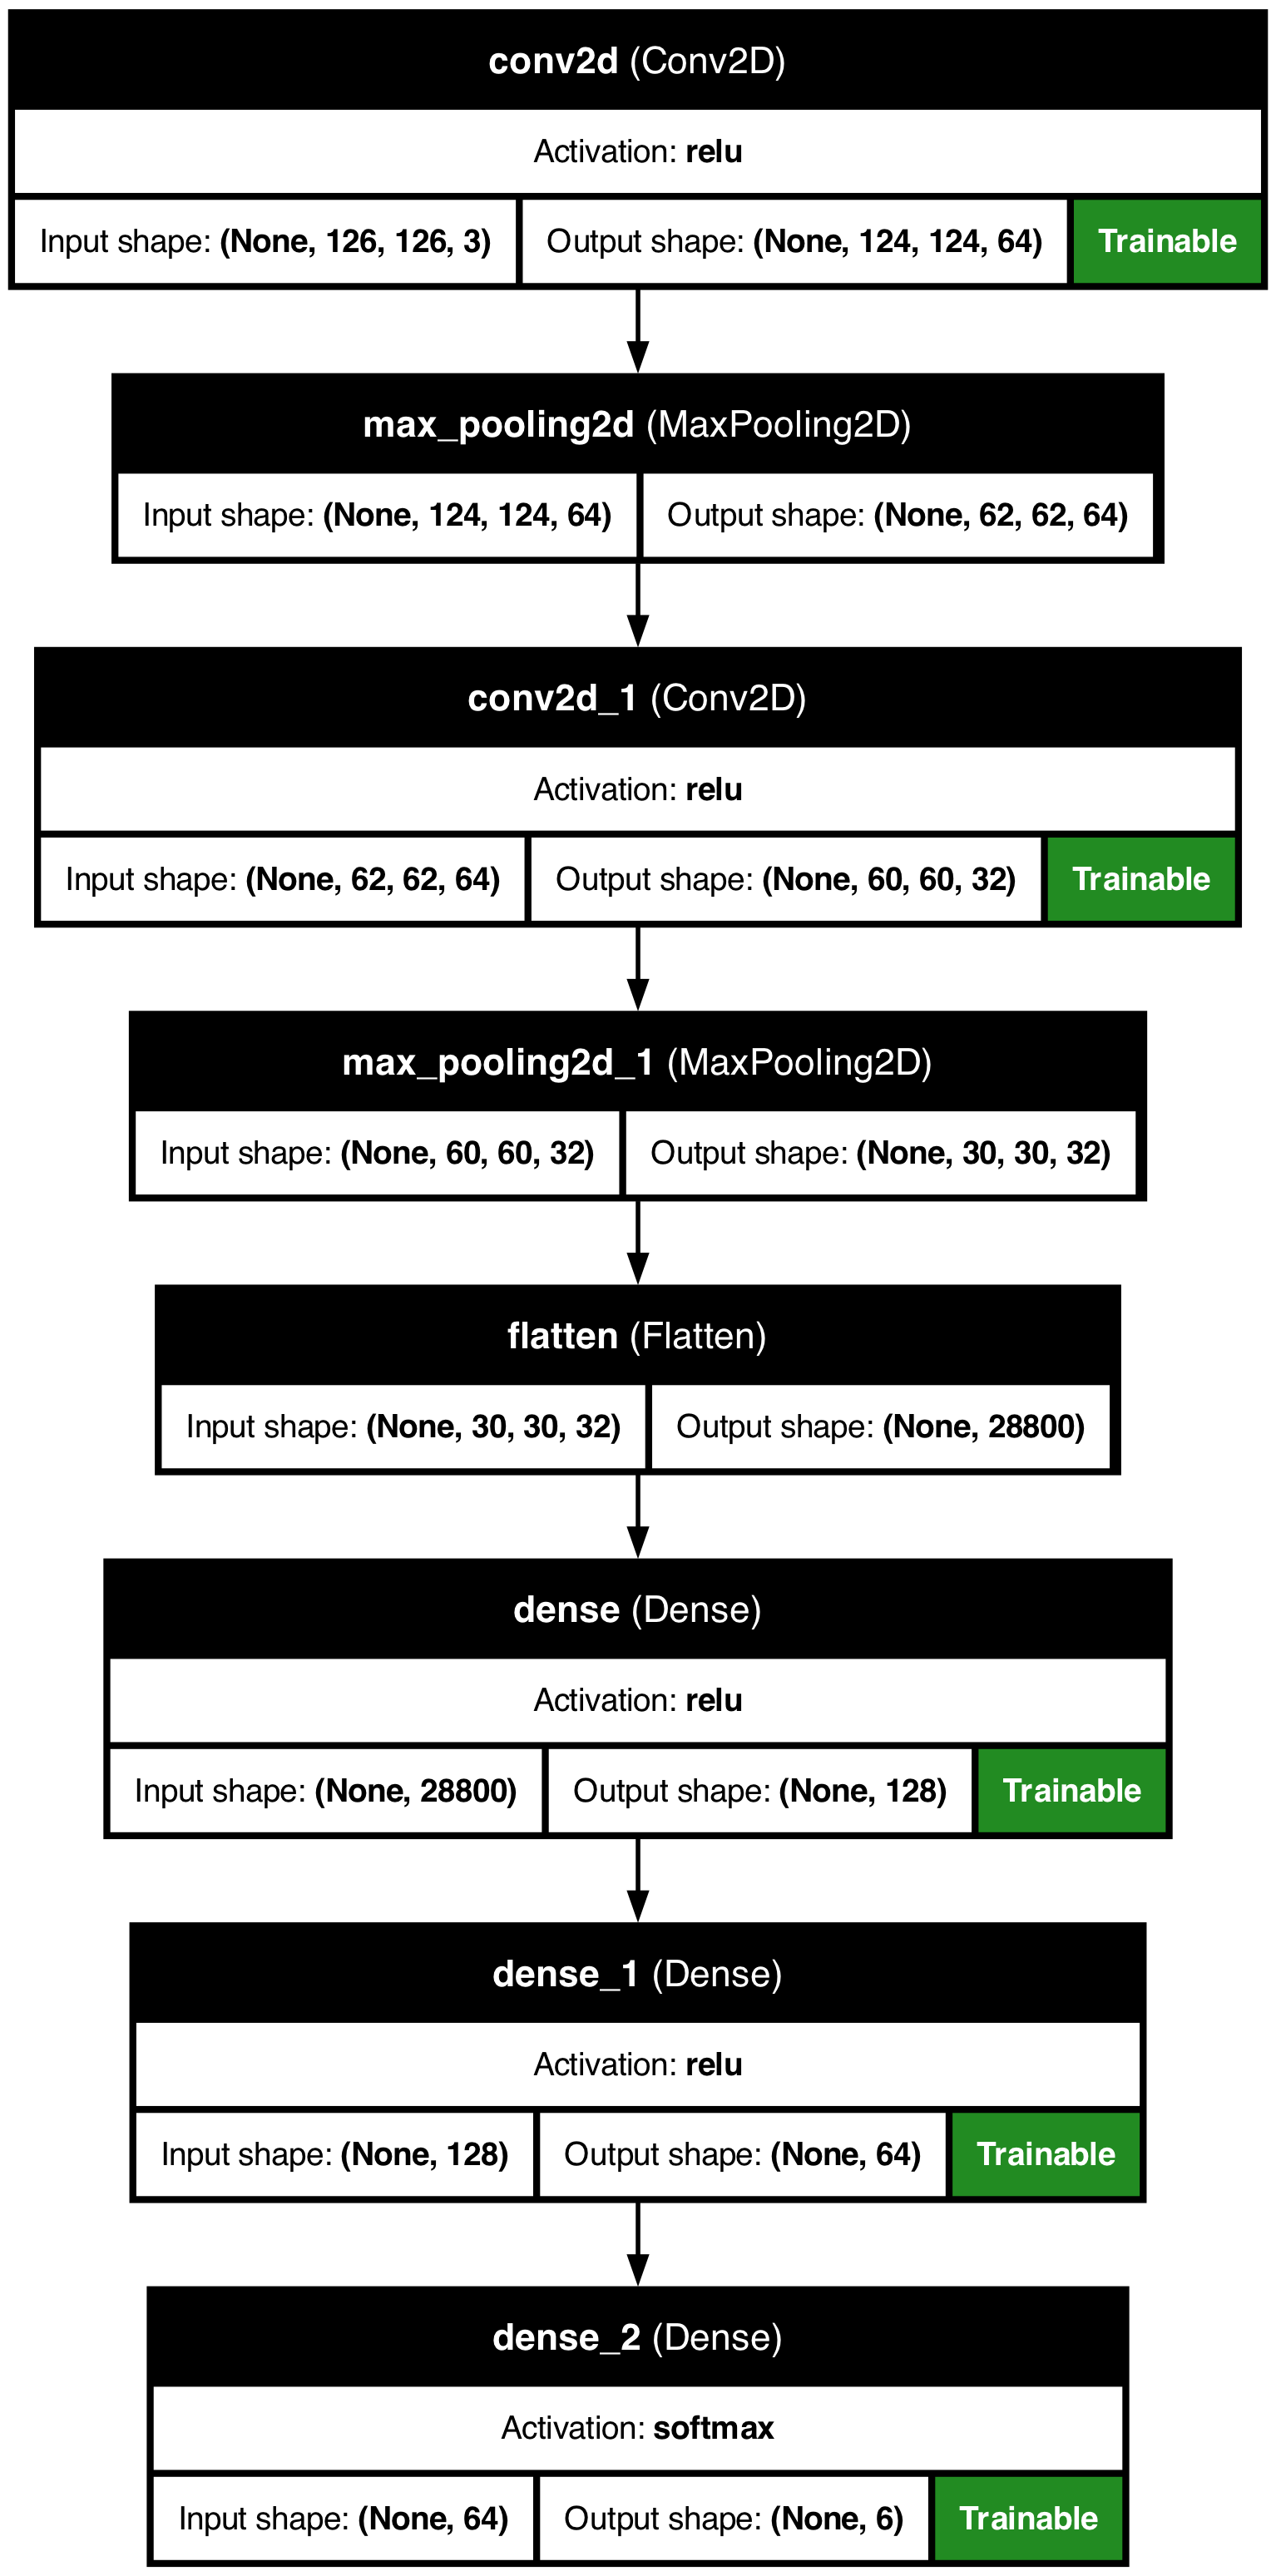

In [8]:
# 2) 
model.summary()
keras.utils.plot_model(model, "openair_cnn.png", show_shapes=True, show_layer_names=True, show_layer_activations=True, show_trainable=True)
Image(filename="openair_cnn.png", width=400)

In [9]:
# 3)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 4)
root_logdir = os.path.join(os.curdir, "my_logs")
logdir = os.path.join(root_logdir, "run_{}".format(time.time()))

%load_ext tensorboard
%tensorboard --logdir {root_logdir}

history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    validation_data=(X_test, y_test), 
    callbacks=[
        keras.callbacks.TensorBoard(log_dir=logdir),
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, mode="max", restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("openair_cnn.keras", save_best_only=True)
    ]
)

Reusing TensorBoard on port 6007 (pid 94020), started 1 day, 0:37:41 ago. (Use '!kill 94020' to kill it.)

Epoch 1/20


2026-04-15 00:02:13.778744: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4313 - loss: 1.4951 - val_accuracy: 0.5200 - val_loss: 1.2297
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5685 - loss: 1.1281 - val_accuracy: 0.5497 - val_loss: 1.1159
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6093 - loss: 1.0322 - val_accuracy: 0.6077 - val_loss: 1.0354
Epoch 4/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6284 - loss: 0.9917 - val_accuracy: 0.6300 - val_loss: 0.9868
Epoch 5/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6445 - loss: 0.9545 - val_accuracy: 0.6177 - val_loss: 0.9862
Epoch 6/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6560 - loss: 0.9315 - val_accuracy: 0.6327 - val_loss: 0.9470
Epoch 7/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6648 - loss: 0.9072 - val_accuracy: 0.6483 - val_loss: 0.9349
Epoch 8/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6769 - loss: 0.8861 - val_accuracy: 0.67

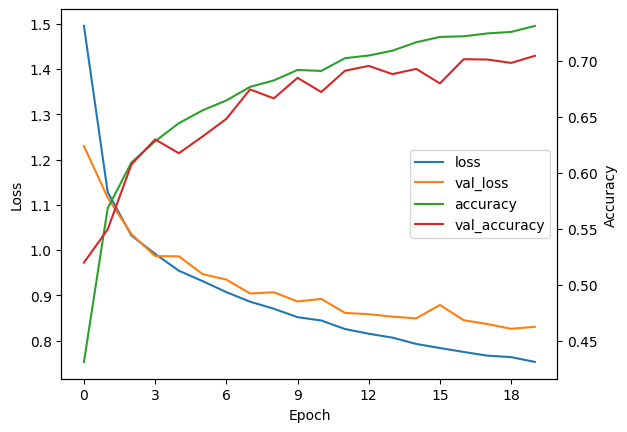

In [10]:
# 5)



# pd.DataFrame(history.history).plot(figsize=(8, 5), grid=True, xlabel="Epochs")

def plot_learning_curves(history):
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    
    l1, = ax1.plot(history.history['loss'], '-', color='C0', label='loss')
    l2, = ax1.plot(history.history['val_loss'], '-', color='C1', label='val_loss')

    l3, = ax2.plot(history.history['accuracy'], '-', color='C2', label='accuracy')
    l4, = ax2.plot(history.history['val_accuracy'], '-', color='C3', label='val_accuracy')
    
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel('Loss')

    ax2.set_ylabel('Accuracy')
    
    plt.legend(handles=[l1, l2, l3, l4], loc='center right')
    return fig, ax1, ax2

fig, ax1, ax2 = plot_learning_curves(history)
plt.show()

    


In [11]:
# 6)
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# 7)
# Display a few Images from test set
first_rand_idx = random.randint(a=0, b=len(test_preds) - 1)
sec_rand_idx = random.randint(a=0, b=len(test_preds) - 1)
third_rand_idx = random.randint(a=0, b=len(test_preds) - 1)

439/439 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [12]:
def plot_predicted_image_with_softmax_probas(idx: int) -> None:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(X_test[idx], interpolation='nearest')
    plt.axis("off")
    plt.title(f"Predicted label: {np.argmax(test_preds[idx])}, true label {y_test[idx]}")

    plt.subplot(1, 2, 2)
    plt.bar(range(NUM_CLASSES_TEST), test_preds[idx])
    plt.xticks(range(NUM_CLASSES_TEST))
    plt.xlabel('Digit')
    plt.ylabel('Probability')
    plt.title('Softmax Probabilities')
    plt.subplots_adjust(wspace=0.4)
    plt.show()

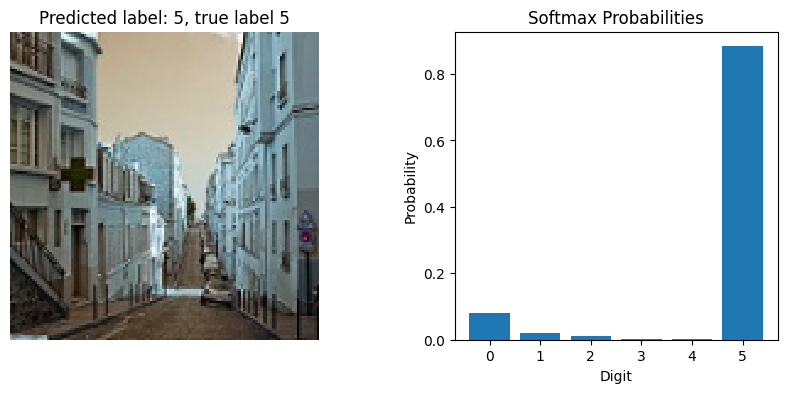

In [13]:
plot_predicted_image_with_softmax_probas(first_rand_idx)

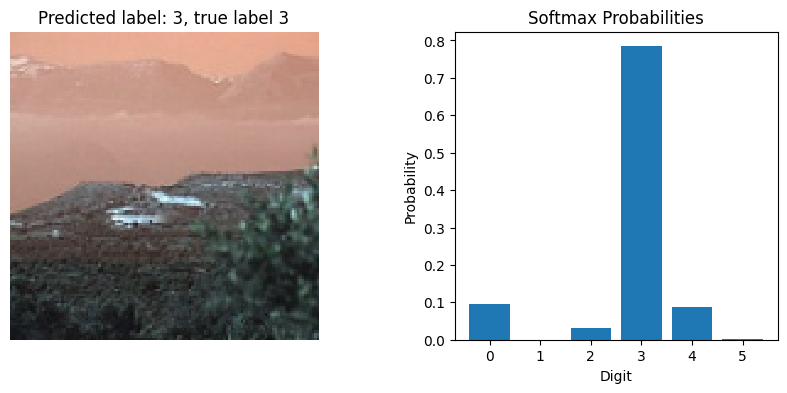

In [14]:
plot_predicted_image_with_softmax_probas(sec_rand_idx)

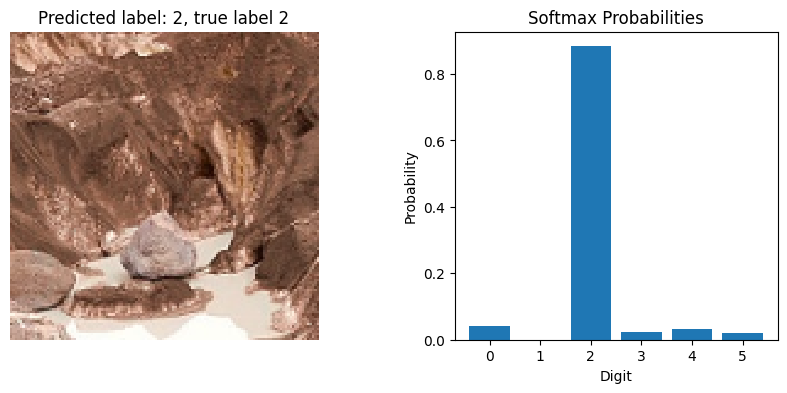

In [15]:
plot_predicted_image_with_softmax_probas(third_rand_idx)

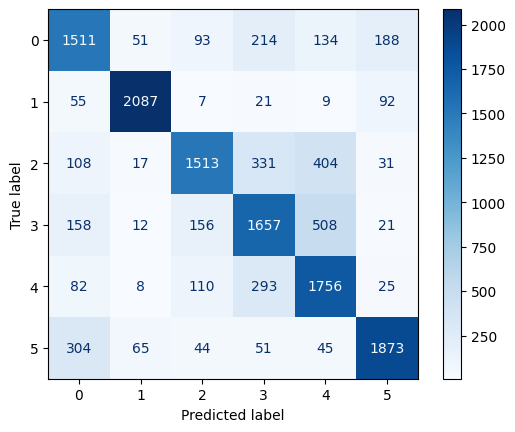

In [29]:
# 8) 
y_train_preds_to_labes = np.argmax(train_preds, axis=1)

# train set conf matrix
cm_train_set = confusion_matrix(y_true=y_train, y_pred=y_train_preds_to_labes)
disp_train_cm = ConfusionMatrixDisplay(cm_train_set)
disp_train_cm.plot(cmap="Blues")

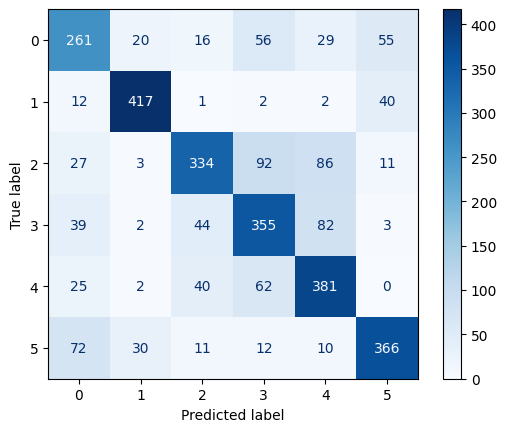

In [31]:
# test set conf matrix
y_test_preds_to_labes = np.argmax(test_preds, axis=1)

cm_train_set = confusion_matrix(y_true=y_test, y_pred=y_test_preds_to_labes)
disp_train_cm = ConfusionMatrixDisplay(cm_train_set)
disp_train_cm.plot(cmap="Blues")

In [35]:
acc_train = accuracy_score(y_true=y_train, y_pred=y_train_preds_to_labes)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_preds_to_labes)

print(f"Train set acc: {acc_train}, test set acc: {acc_test}")

Train set acc: 0.7408436653840673, test set acc: 0.7046666666666667


In [ ]:
# 9) First training summary: